In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
fields = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for field in fields:
    print(field, df[field].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


In [6]:
df['Sex'] = (df['Sex'] == 'M').astype(np.int8)

In [7]:
df['ExerciseAngina'] = (df['ExerciseAngina'] == 'Y').astype(np.int8)

In [8]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [9]:
from sklearn.preprocessing import OneHotEncoder

heart_cat = df[['ChestPainType', 'RestingECG', 'ST_Slope']]

onehot_enc = OneHotEncoder()
heart_cat_enc = onehot_enc.fit_transform(heart_cat)

In [10]:
heart_cat_enc.toarray()

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 1.]], shape=(918, 10))

In [11]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [12]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
df[['ST_Slope', 'RestingECG']] = ord_enc.fit_transform(df[['ST_Slope', 'RestingECG']])

In [13]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,1.0,172,0,0.0,2.0,0
1,49,0,NAP,160,180,0,1.0,156,0,1.0,1.0,1
2,37,1,ATA,130,283,0,2.0,98,0,0.0,2.0,0
3,48,0,ASY,138,214,0,1.0,108,1,1.5,1.0,1
4,54,1,NAP,150,195,0,1.0,122,0,0.0,2.0,0


In [14]:
df = df.drop(columns="ChestPainType")

In [15]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,140,289,0,1.0,172,0,0.0,2.0,0
1,49,0,160,180,0,1.0,156,0,1.0,1.0,1
2,37,1,130,283,0,2.0,98,0,0.0,2.0,0
3,48,0,138,214,0,1.0,108,1,1.5,1.0,1
4,54,1,150,195,0,1.0,122,0,0.0,2.0,0


In [16]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns="HeartDisease"), df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

/home/haider/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred_logistic = log_reg.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_test, y_pred_logistic)

print(score)

0.7934782608695652


In [20]:
from sklearn.svm import SVC

svm_clf = SVC()

svm_clf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
y_pred_svc = svm_clf.predict(X_test)

In [22]:
score = accuracy_score(y_test, y_pred_svc)
print(score)

0.6847826086956522


In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier()

tree_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred_tree = tree_clf.predict(X_test)

In [25]:
score = accuracy_score(y_test, y_pred_tree)
print(score)

0.8152173913043478


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier()

rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_forest = rf_clf.predict(X_test)

In [28]:
score = accuracy_score(y_test, y_pred_forest)
print(score)

0.8478260869565217


Raw Matrix:
 [[66 11]
 [17 90]]


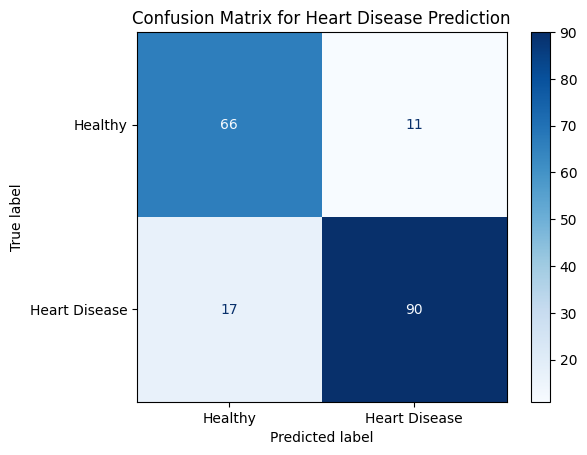

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_forest)
print("Raw Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Heart Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Heart Disease Prediction")
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_forest, target_names=['Healthy', 'Heart Disease']))

               precision    recall  f1-score   support

      Healthy       0.80      0.86      0.82        77
Heart Disease       0.89      0.84      0.87       107

     accuracy                           0.85       184
    macro avg       0.84      0.85      0.85       184
 weighted avg       0.85      0.85      0.85       184



In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(learning_rate=0.75)
gb_clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.75
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [32]:
y_pred_boost = gb_clf.predict(X_test)

In [33]:
score = accuracy_score(y_test, y_pred_boost)
print(score)

0.8206521739130435


In [34]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_grid_search = GridSearchCV(estimator=rf_clf, 
                              param_grid=rf_param_grid, 
                              cv=5, 
                              scoring='f1', 
                              n_jobs=-1)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid_search.best_params_)
print("Best Cross-Validated F1-Score:", rf_grid_search.best_score_)

Best Random Forest Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validated F1-Score: 0.8890253889122723


In [35]:
gb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}


gb_grid_search = GridSearchCV(estimator=gb_clf, 
                              param_grid=gb_param_grid, 
                              cv=5, 
                              scoring='f1', 
                              n_jobs=-1)

gb_grid_search.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid_search.best_params_)
print("Best Cross-Validated F1-Score:", gb_grid_search.best_score_)

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Best Cross-Validated F1-Score: 0.8833937112730815


In [36]:
best_rf = rf_grid_search.best_estimator_
best_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred_best_rf = best_rf.predict(X_test)

In [38]:
score = accuracy_score(y_test, y_pred_best_rf)
print(score)

0.8532608695652174
